# Loading Libraries

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Setup path
root_path = Path(r'C:\Users\shiva\Desktop\Ensemble_Partner_Hiring_Assignment\Hiring Assessment - AI Team - Classical ML + Gen AI problem (ML + basic Gen AI) (1)\Hiring Assessment - AI Team - Classical ML + Gen AI problem')
data_path = root_path / 'data'

# Useful Utilities

In [3]:
# utilities 
def set_title(title):
    print('#'*100)
    print(title)
    print('#'*100)


# Get basic details
def get_basic_details(data):
    print(f'Shape of data {data.shape}\n')
    print(f'columns in data \n {data.columns.to_list()}\n')
    print(f'data types of data\n {data.dtypes}\n')
    print(f'missing values \n {data.isnull().any()}\n')

In [4]:
hist = pd.read_csv(data_path / 'claims_history.csv')
curr = pd.read_csv(data_path / 'current_claims.csv')


In [5]:
set_title("1. Basic Details - Historic data")
get_basic_details(hist)

####################################################################################################
1. Basic Details - Historic data
####################################################################################################
Shape of data (3200, 20)

columns in data 
 ['claim_id', 'payer_id', 'payer_type', 'visit_type', 'total_billed', 'expected_payment', 'num_procedures', 'num_diagnoses', 'prior_auth_required', 'has_prior_auth', 'is_in_network', 'days_to_submit', 'missing_documentation_flag', 'eligibility_verified', 'referral_required', 'referral_present', 'split', 'service_month', 'is_denied', 'denial_reason']

data types of data
 claim_id                       object
payer_id                       object
payer_type                     object
visit_type                     object
total_billed                  float64
expected_payment              float64
num_procedures                  int64
num_diagnoses                   int64
prior_auth_required             int64
has_pri

In [6]:
set_title("1. Basic Details - Current data")
get_basic_details(curr)

####################################################################################################
1. Basic Details - Current data
####################################################################################################
Shape of data (500, 17)

columns in data 
 ['claim_id', 'payer_id', 'payer_type', 'visit_type', 'total_billed', 'expected_payment', 'num_procedures', 'num_diagnoses', 'prior_auth_required', 'has_prior_auth', 'is_in_network', 'days_to_submit', 'missing_documentation_flag', 'eligibility_verified', 'referral_required', 'referral_present', 'service_month']

data types of data
 claim_id                       object
payer_id                       object
payer_type                     object
visit_type                     object
total_billed                  float64
expected_payment              float64
num_procedures                  int64
num_diagnoses                   int64
prior_auth_required             int64
has_prior_auth                  int64
is_in_netw

In [77]:
target_cols = ['is_denied', 'denial_reason']
index_cols = ['claim_id']
obj_cols = hist.select_dtypes(include='object').columns.to_list()
num_cols = hist.select_dtypes(exclude='object').columns.to_list()

flag_cols = ['has_prior_auth','prior_auth_required', \
            'referral_required','referral_present', \
            'missing_documentation_flag',
            'eligibility_verified','is_in_network']

# remove the index col, target variable
num_cols = list(set(num_cols) - set(['is_denied']))
obj_cols = list(set(obj_cols) - set(['claim_id']))

# removing the flag_cols from num_cols
num_cols = list(set(num_cols) - set(flag_cols))

# Target Exploration

####################################################################################################
2. Target Exploration
####################################################################################################


Target distribution
   is_denied  proportion
0          0    0.784062
1          1    0.215938




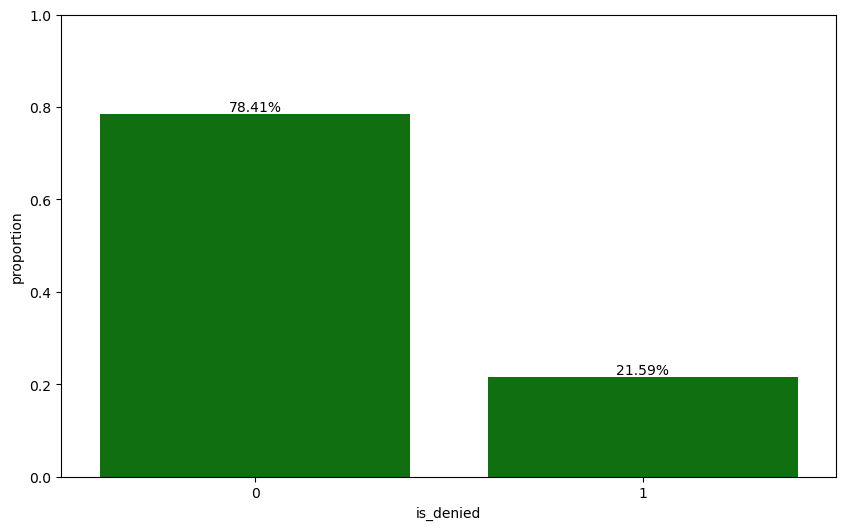

In [78]:
set_title('2. Target Exploration')
target_dist = hist['is_denied'].value_counts(normalize=True)
target_dist = pd.DataFrame(target_dist).reset_index(drop=False)

print('\n')
print('Target distribution')
print(target_dist)
print('\n')

plt.figure(figsize = (10,6))
ax = sns.barplot(target_dist,x = 'is_denied', y = 'proportion', color='green')

# Add labels on bars
for i, row in target_dist.iterrows():
    ax.text(
        i,
        row['proportion'],
        f"{row['proportion']:.2%}",   # or f"{row['proportion']:.2f}"
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylim(0,1)
plt.show()

# Target Exploration with variables

####################################################################################################
3.1 Variation of Numeric variables with target
####################################################################################################
                  is_denied = 0  is_denied = 1
is_denied              0.000000       1.000000
num_procedures         3.760861       4.166425
total_billed       11619.203663   14144.022460
days_to_submit        18.607812      21.661360
num_diagnoses          5.222001       5.657019
expected_payment    5866.160012    6634.914602


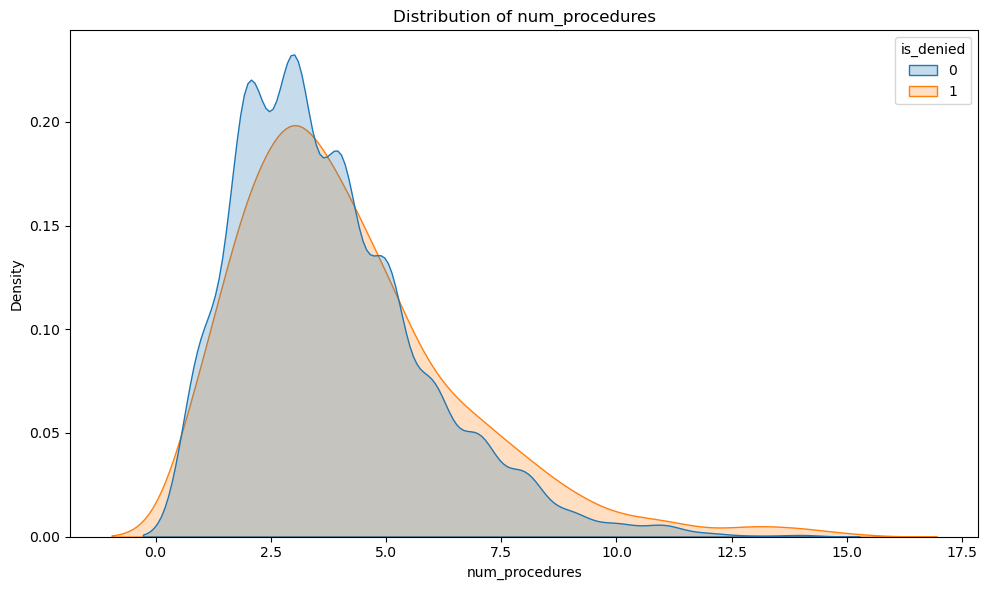

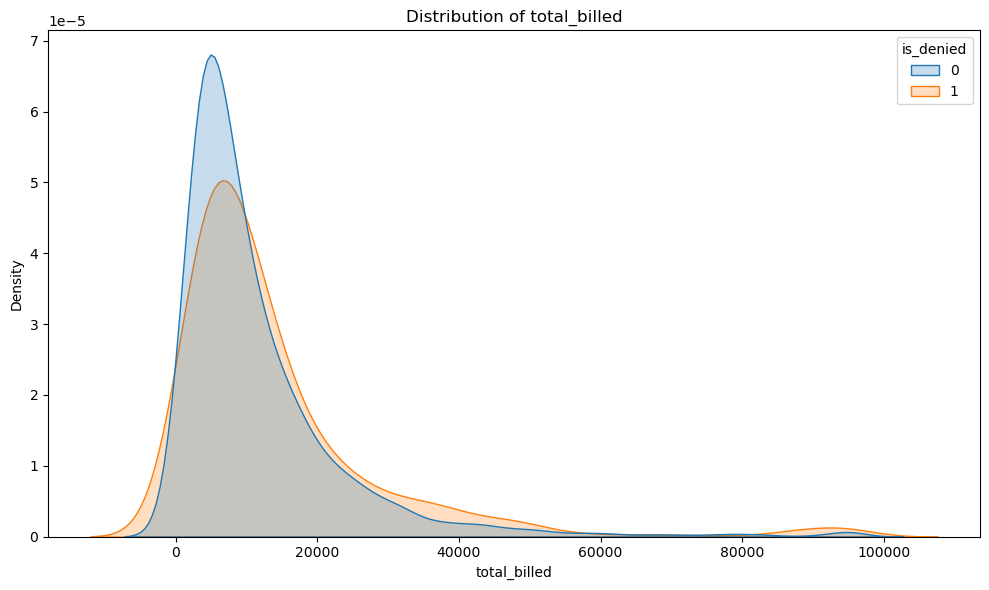

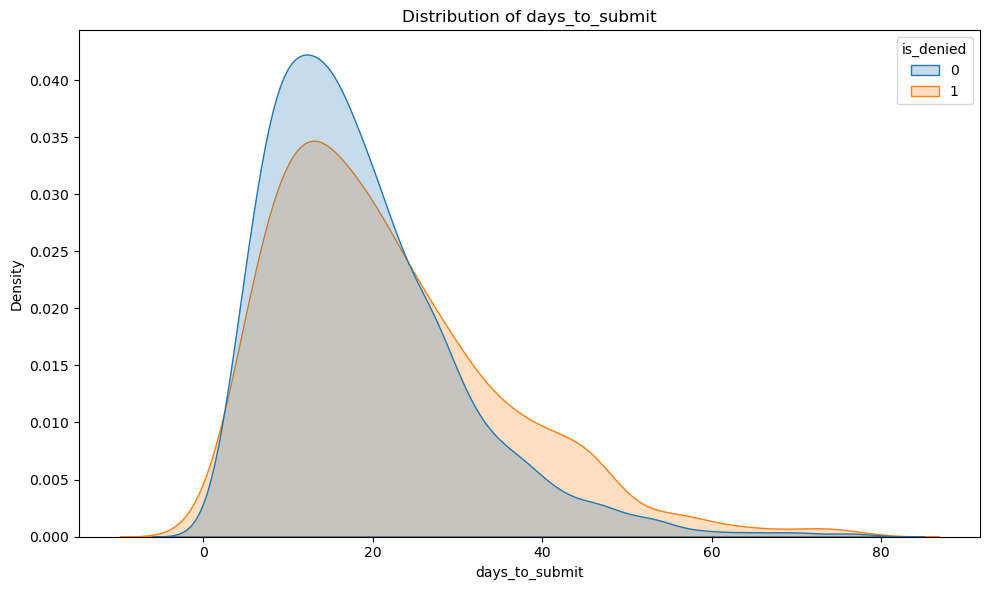

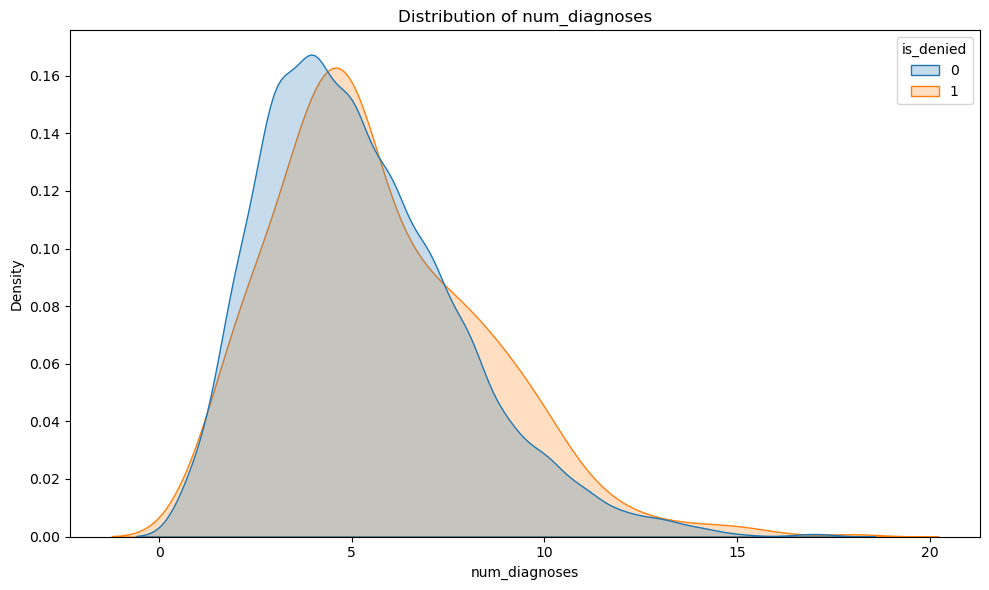

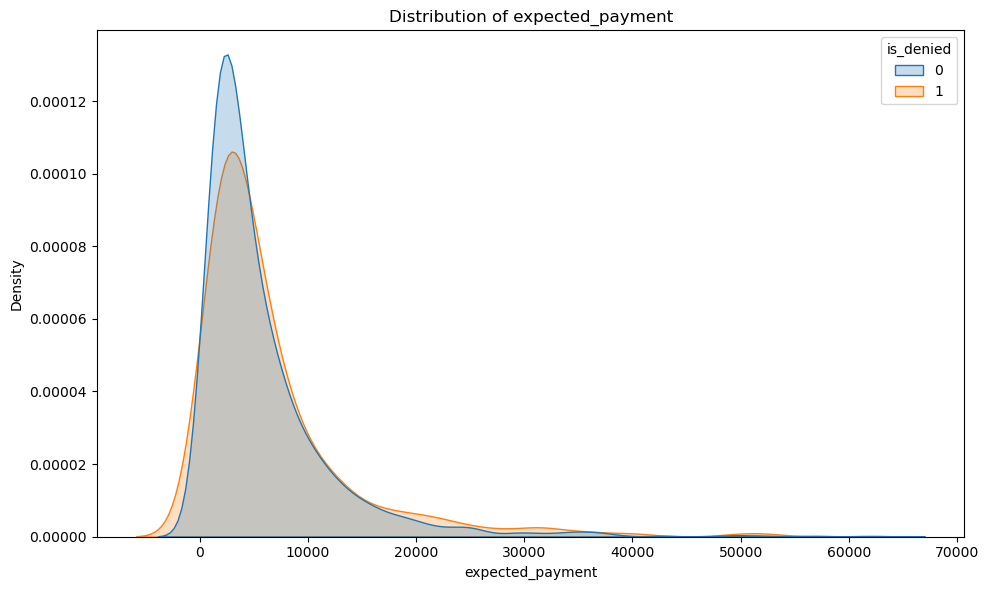

In [84]:
set_title('3.1 Variation of Numeric variables with target')

numeric_data = hist[num_cols + ['is_denied']].groupby('is_denied').mean().reset_index(drop=False).transpose()
numeric_data.columns = ['is_denied = 0','is_denied = 1']
print(numeric_data)

for col in num_cols:
    plt.figure(figsize=(10, 6))

    sns.kdeplot(
        data=hist,
        x=col,
        hue='is_denied',
        fill=True,
        common_norm=False
    )

    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

In [111]:
set_title('3.2 Variation of categorical variables with target')
print(f"Base denial rate: {hist['is_denied'].mean()}")

for col in obj_cols:
    print(f"\n{col}")
    print(hist.groupby(col)['is_denied'].mean().sort_values(ascending=False))
    print('-' * 50)

####################################################################################################
3.2 Variation of categorical variables with target
####################################################################################################
Base denial rate: 0.2159375

payer_type
payer_type
Medicaid MCO          0.305520
Medicare Advantage    0.254480
BCBS                  0.212766
Commercial            0.149331
Name: is_denied, dtype: float64
--------------------------------------------------

service_month
service_month
2024-11    0.260417
2024-12    0.258964
2024-01    0.248175
2024-07    0.230469
2024-08    0.229630
2024-03    0.222222
2024-02    0.200000
2024-05    0.200000
2024-10    0.197880
2024-04    0.190840
2024-09    0.183594
2024-06    0.167260
Name: is_denied, dtype: float64
--------------------------------------------------

visit_type
visit_type
Inpatient      0.305723
Outpatient     0.199729
Emergency      0.182764
Observation    0.181347
Name: is_denied, d

In [122]:
set_title('3.2.1 Variation of categorical variables with target')

denial_reason = pd.DataFrame(hist['denial_reason'].value_counts(normalize=True).reset_index())
denial_reason.columns  = ['denial_reason','Perc of records']
denial_reason['Perc of records'] = denial_reason['Perc of records']*100
denial_reason

####################################################################################################
3.2.1 Variation of categorical variables with target
####################################################################################################


,denial_reason,Perc of records
0,Payer policy or medical necessity issue,20.260492
1,Documentation incomplete or missing,17.076700
2,Patient eligibility could not be verified,13.314038
3,Claim submitted after timely filing deadline,12.011577
4,Authorization required but not on file,10.564399
5,Procedure or diagnosis coding error,9.985528
6,Provider not in network for this payer,9.696093
7,Referral required but not present,7.091172


In [141]:
set_title("3.3 New features engineered")

flag_cols = ['has_prior_auth','prior_auth_required', \
            'referral_required','referral_present', \
            'missing_documentation_flag',
            'eligibility_verified','is_in_network']


hist_e = hist.copy()
hist_e['prior_auth_gap'] = np.where(((hist_e['has_prior_auth'] ==0) & (hist_e['prior_auth_required']==1)),1,0)
hist_e['referral_gap'] = np.where(((hist_e['referral_required'] ==1) & (hist_e['referral_present']==0)),1,0)

# payment_ratio: how much of the billed amount the payer is expected to cover.
# Guard against divide-by-zero on total_billed, then fill the resulting NaNs with 0.
hist_e['payment_ratio'] = hist_e['expected_payment'] / hist_e['total_billed'].replace(0, np.nan)
hist_e['payment_ratio'] = hist_e['payment_ratio'].fillna(0)

# log_total_billed: compress the heavy right tail of billed amounts (log1p handles 0).
hist_e['log_total_billed'] = np.log1p(hist_e['total_billed'])

print("Prior Authorization Gap")
print(hist_e[['prior_auth_gap','is_denied']].value_counts(normalize=True).reset_index())

print("\nReferral Gap")
print(hist_e[['referral_gap','is_denied']].value_counts(normalize=True).reset_index())

# Continuous features -> compare the mean by target instead of value_counts.
print("\nPayment Ratio & Log Total Billed (mean by target)")
print(hist_e.groupby('is_denied')[['payment_ratio','log_total_billed']].mean())

print("\nPayment Ratio & Log Total Billed (summary)")
print(hist_e[['payment_ratio','log_total_billed']].describe())

####################################################################################################
3.3 New features engineered
####################################################################################################
Prior Authorization Gap
   prior_auth_gap  is_denied  proportion
0               0          0    0.732187
1               0          1    0.170937
2               1          0    0.051875
3               1          1    0.045000

Referral Gap
   referral_gap  is_denied  proportion
0             0          0    0.729375
1             0          1    0.189062
2             1          0    0.054688
3             1          1    0.026875

Payment Ratio & Log Total Billed (mean by target)
           payment_ratio  log_total_billed
is_denied                                 
0               0.503821          8.968935
1               0.467777          9.142602

Payment Ratio & Log Total Billed (summary)
       payment_ratio  log_total_billed
count    3200.000000      

####################################################################################################
3.4 Mutual information metric with feature
####################################################################################################
                       Feature  Mutual Information
13  missing_documentation_flag            0.017871
16              prior_auth_gap            0.016646
8                     payer_id            0.015443
5                   payer_type            0.012046
14        eligibility_verified            0.008290
3                num_diagnoses            0.006418
7                   visit_type            0.006056
10         prior_auth_required            0.004839
0               num_procedures            0.004498
17                referral_gap            0.003079
6                service_month            0.002545
18               payment_ratio            0.001240
11           referral_required            0.000851
15               is_in_network           

C:\Users\shiva\AppData\Local\Temp\ipykernel_28048\1150763836.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


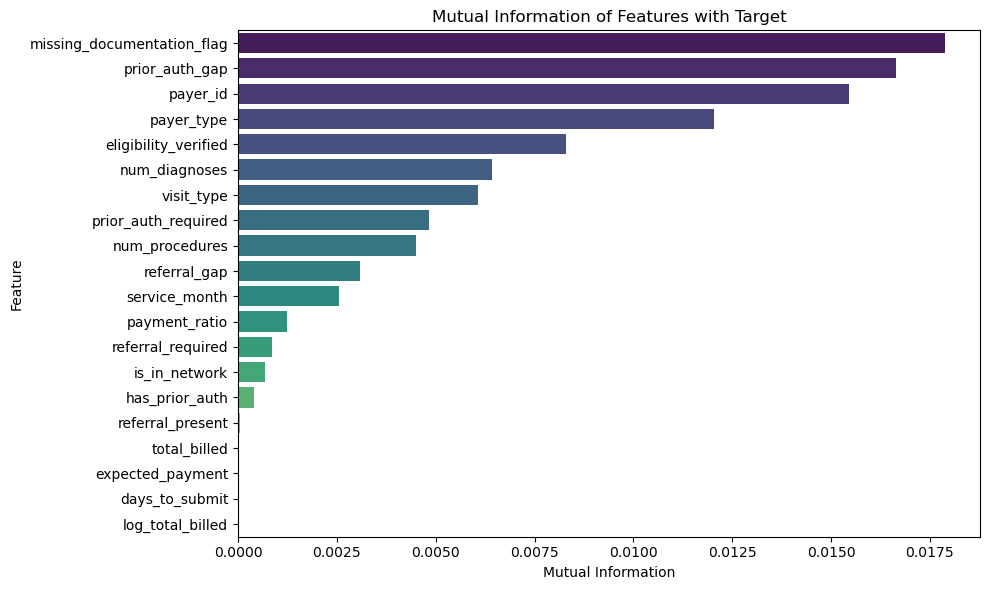

In [ ]:
set_title("3.4 Mutual information metric with feature")

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

feature_obj_cols = [c for c in obj_cols if c not in ('denial_reason', 'split')]

continuous_cols = ['total_billed', 'expected_payment', 'days_to_submit',
                   'payment_ratio', 'log_total_billed']

feature_cols = (num_cols + feature_obj_cols + flag_cols +
                ['prior_auth_gap', 'referral_gap', 'payment_ratio', 'log_total_billed'])
X = hist_e[feature_cols].copy()
y = hist_e['is_denied']

# Encode only the categorical (object) columns; leave numerics as-is.
for col in feature_obj_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

discrete_mask = [col not in continuous_cols for col in X.columns]

mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

mi_df = (
    pd.DataFrame({
        'Feature': X.columns,
        'Mutual Information': mi
    })
    .sort_values('Mutual Information', ascending=False)
)

print(mi_df)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=mi_df,
    x='Mutual Information',
    y='Feature',
    palette='viridis'
)

plt.title('Mutual Information of Features with Target')
plt.tight_layout()
plt.show()